# DSI310 – Chinook & Northwind Source Exploration

Task 1 explores the source schemas, row volumes, keys, and relationships in the Chinook and Northwind SQLite databases. SQLite internal tables (names beginning with `sqlite_`) are reported separately and excluded from business-table analysis.

## 1. Setup

In [18]:
%pip install -q pandas sqlalchemy requests matplotlib

Note: you may need to restart the kernel to use updated packages.


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from sqlalchemy import create_engine, inspect, text

In [20]:
# Source locations supplied by the starter notebook.
CHINOOK_URL = (
    "https://raw.githubusercontent.com/lerocha/chinook-database/master/"
    "ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
)
NORTHWIND_URL = (
    "https://github.com/jpwhite3/northwind-SQLite3/raw/main/dist/northwind.db"
)

DATA_DIR = Path("data")
CHINOOK_DB_PATH = DATA_DIR / "chinook.db"
NORTHWIND_DB_PATH = DATA_DIR / "northwind.db"

### 1.1 Reusable helper functions

In [21]:
def download_file(url, destination):
    """Download a source file unless a non-empty local copy already exists."""
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and destination.stat().st_size > 0:
        print(f"'{destination}' already exists. Skipping download.")
        return destination

    print(f"Downloading {destination.name}...")
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        with destination.open("wb") as output_file:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    output_file.write(chunk)

    print(f"Saved '{destination}'.")
    return destination


def get_business_tables(engine):
    """Return business tables and SQLite internal tables separately."""
    table_names = inspect(engine).get_table_names(sqlite_include_internal=True)
    system_tables = sorted(
        table_name for table_name in table_names if table_name.startswith("sqlite_")
    )
    business_tables = sorted(
        table_name for table_name in table_names if not table_name.startswith("sqlite_")
    )
    return business_tables, system_tables


def collect_source_metadata(engine, source_system):
    """Build dynamic table, column, and foreign-key inventories for one source."""
    inspector = inspect(engine)
    table_names, system_tables = get_business_tables(engine)
    quote_identifier = engine.dialect.identifier_preparer.quote

    table_rows = []
    column_rows = []
    foreign_key_rows = []

    with engine.connect() as connection:
        for table_name in table_names:
            quoted_table = quote_identifier(table_name)
            record_count = connection.execute(
                text(f"SELECT COUNT(*) FROM {quoted_table}")
            ).scalar_one()
            table_rows.append(
                {"SourceSystem": source_system, "TableName": table_name, "RecordCount": record_count}
            )

            primary_key_columns = set(
                inspector.get_pk_constraint(table_name).get("constrained_columns") or []
            )
            for column in inspector.get_columns(table_name):
                column_rows.append(
                    {
                        "SourceSystem": source_system,
                        "TableName": table_name,
                        "ColumnName": column["name"],
                        "DataType": str(column["type"]),
                        "Nullable": bool(column.get("nullable", True)),
                        "IsPrimaryKey": column["name"] in primary_key_columns,
                    }
                )

            for foreign_key in inspector.get_foreign_keys(table_name):
                from_columns = foreign_key.get("constrained_columns") or []
                to_columns = foreign_key.get("referred_columns") or []
                for from_column, to_column in zip(from_columns, to_columns):
                    foreign_key_rows.append(
                        {
                            "SourceSystem": source_system,
                            "FromTable": table_name,
                            "FromColumn": from_column,
                            "ToTable": foreign_key["referred_table"],
                            "ToColumn": to_column,
                        }
                    )

    table_inventory = pd.DataFrame(
        table_rows, columns=["SourceSystem", "TableName", "RecordCount"]
    )
    column_inventory = pd.DataFrame(
        column_rows,
        columns=["SourceSystem", "TableName", "ColumnName", "DataType", "Nullable", "IsPrimaryKey"],
    )
    foreign_key_inventory = pd.DataFrame(
        foreign_key_rows,
        columns=["SourceSystem", "FromTable", "FromColumn", "ToTable", "ToColumn"],
    )
    return table_inventory, column_inventory, foreign_key_inventory, system_tables

## 2. Download Source Databases

In [22]:
download_file(CHINOOK_URL, CHINOOK_DB_PATH)
download_file(NORTHWIND_URL, NORTHWIND_DB_PATH)

'data\chinook.db' already exists. Skipping download.
'data\northwind.db' already exists. Skipping download.


WindowsPath('data/northwind.db')

## 3. Database Connections

In [23]:
chinook_engine = create_engine(f"sqlite:///{CHINOOK_DB_PATH.as_posix()}", echo=False)
northwind_engine = create_engine(f"sqlite:///{NORTHWIND_DB_PATH.as_posix()}", echo=False)

for source_name, engine in {
    "Chinook": chinook_engine,
    "Northwind": northwind_engine,
}.items():
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print(f"Connection to {source_name} established successfully.")

Connection to Chinook established successfully.
Connection to Northwind established successfully.


## 4. Source Metadata Inventory

The inventories below are generated from the downloaded databases. Tables whose names begin with `sqlite_` are SQLite implementation tables, so they are listed explicitly but excluded from business-table counts, schema analysis, relationships, and charts.

In [24]:
metadata_results = {}
for source_name, engine in {
    "Chinook": chinook_engine,
    "Northwind": northwind_engine,
}.items():
    metadata_results[source_name] = collect_source_metadata(engine, source_name)

table_inventory_df = pd.concat(
    [result[0] for result in metadata_results.values()], ignore_index=True
).sort_values(["SourceSystem", "TableName"], ignore_index=True)
column_inventory_df = pd.concat(
    [result[1] for result in metadata_results.values()], ignore_index=True
).sort_values(["SourceSystem", "TableName", "ColumnName"], ignore_index=True)
foreign_key_inventory_df = pd.concat(
    [result[2] for result in metadata_results.values()], ignore_index=True
).sort_values(["SourceSystem", "FromTable", "FromColumn"], ignore_index=True)

system_table_inventory_df = pd.DataFrame(
    [
        {
            "SourceSystem": source_name,
            "TableName": table_name,
            "ExclusionReason": "SQLite internal table (sqlite_ prefix)",
        }
        for source_name, result in metadata_results.items()
        for table_name in result[3]
    ],
    columns=["SourceSystem", "TableName", "ExclusionReason"],
)

if system_table_inventory_df.empty:
    print("No SQLite internal tables were found.")
else:
    print("SQLite internal tables excluded from business analysis:")
    display(system_table_inventory_df)

SQLite internal tables excluded from business analysis:


,SourceSystem,TableName,ExclusionReason
0,Northwind,sqlite_sequence,SQLite internal table (sqlite_ prefix)


### 4.1 Table Inventory

In [25]:
display(table_inventory_df)

,SourceSystem,TableName,RecordCount
0,Chinook,Album,347
1,Chinook,Artist,275
2,Chinook,Customer,59
3,Chinook,Employee,8
4,Chinook,Genre,25
5,Chinook,Invoice,412
6,Chinook,InvoiceLine,2240
7,Chinook,MediaType,5
8,Chinook,Playlist,18
9,Chinook,PlaylistTrack,8715


### 4.2 Column and Data Type Inventory

In [26]:
display(column_inventory_df)

,SourceSystem,TableName,ColumnName,DataType,Nullable,IsPrimaryKey
0,Chinook,Album,AlbumId,INTEGER,False,True
1,Chinook,Album,ArtistId,INTEGER,False,False
2,Chinook,Album,Title,NVARCHAR(160),False,False
3,Chinook,Artist,ArtistId,INTEGER,False,True
4,Chinook,Artist,Name,NVARCHAR(120),True,False
...,...,...,...,...,...,...
147,Northwind,Suppliers,Region,TEXT,True,False
148,Northwind,Suppliers,SupplierID,INTEGER,False,True
149,Northwind,Territories,RegionID,INTEGER,False,False
150,Northwind,Territories,TerritoryDescription,TEXT,False,False


### 4.3 Primary and Foreign Key Relationships

Primary-key membership is recorded in `column_inventory_df`; source relationships are listed below.

In [27]:
primary_key_inventory_df = column_inventory_df.loc[
    column_inventory_df["IsPrimaryKey"],
    ["SourceSystem", "TableName", "ColumnName"],
].reset_index(drop=True)

print("Primary keys:")
display(primary_key_inventory_df)
print("Foreign-key relationships:")
display(foreign_key_inventory_df)

Primary keys:


,SourceSystem,TableName,ColumnName
0,Chinook,Album,AlbumId
1,Chinook,Artist,ArtistId
2,Chinook,Customer,CustomerId
3,Chinook,Employee,EmployeeId
4,Chinook,Genre,GenreId
5,Chinook,Invoice,InvoiceId
6,Chinook,InvoiceLine,InvoiceLineId
7,Chinook,MediaType,MediaTypeId
8,Chinook,Playlist,PlaylistId
9,Chinook,PlaylistTrack,PlaylistId


Foreign-key relationships:


,SourceSystem,FromTable,FromColumn,ToTable,ToColumn
0,Chinook,Album,ArtistId,Artist,ArtistId
1,Chinook,Customer,SupportRepId,Employee,EmployeeId
2,Chinook,Employee,ReportsTo,Employee,EmployeeId
3,Chinook,Invoice,CustomerId,Customer,CustomerId
4,Chinook,InvoiceLine,InvoiceId,Invoice,InvoiceId
5,Chinook,InvoiceLine,TrackId,Track,TrackId
6,Chinook,PlaylistTrack,PlaylistId,Playlist,PlaylistId
7,Chinook,PlaylistTrack,TrackId,Track,TrackId
8,Chinook,Track,AlbumId,Album,AlbumId
9,Chinook,Track,GenreId,Genre,GenreId


## 5. Data Volume Exploration

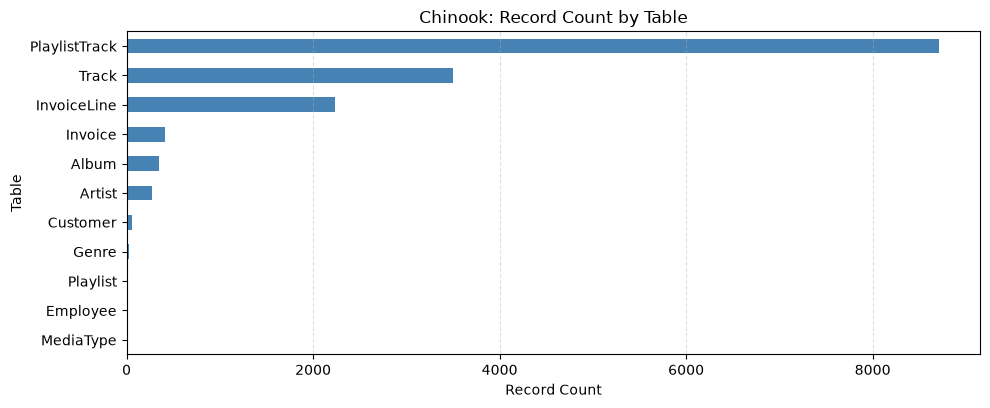

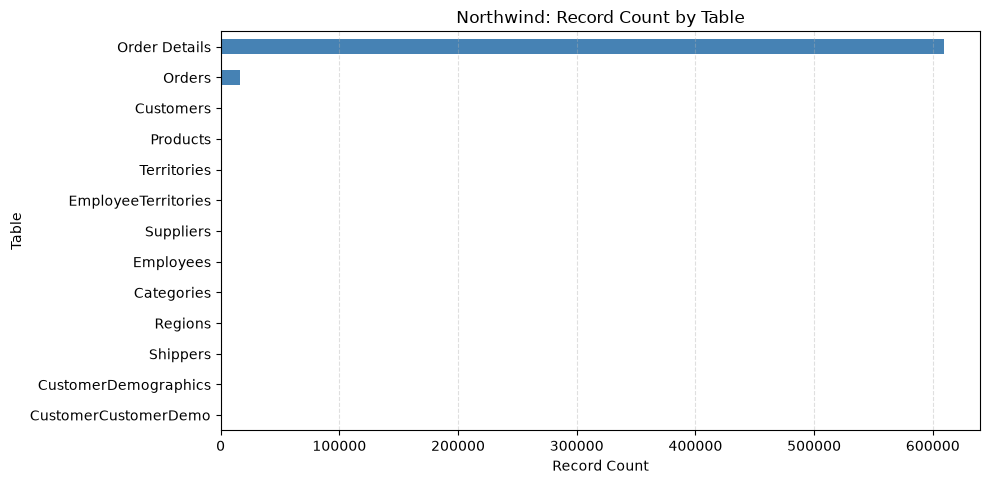

In [28]:
for source_name in ["Chinook", "Northwind"]:
    source_counts = (
        table_inventory_df.loc[
            table_inventory_df["SourceSystem"] == source_name
        ]
        .sort_values("RecordCount", ascending=True)
        .set_index("TableName")["RecordCount"]
    )

    figure_height = max(4, 0.38 * len(source_counts))
    ax = source_counts.plot(
        kind="barh", figsize=(10, figure_height), color="steelblue"
    )
    ax.set_title(f"{source_name}: Record Count by Table")
    ax.set_xlabel("Record Count")
    ax.set_ylabel("Table")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

## 6. Source Database Schema Diagrams

The source schemas are inspected programmatically using SQLAlchemy, and DBML definitions are generated from the resulting metadata DataFrames. dbdiagram.io is used to render those definitions and manually arrange the final database schema diagrams for readability. The SQLite source schemas remain the source of truth, so the database schema definitions originate from code and inspected metadata; only the visual layout is manually arranged.

### 6.1 Chinook Database Schema Diagram

![Chinook database schema diagram](../docs/diagrams/chinook_database_schema.png)

The Chinook database schema diagram shows the source tables, columns, datatypes, primary keys, foreign keys, and table relationships.

### 6.2 Northwind Database Schema Diagram

![Northwind database schema diagram](../docs/diagrams/northwind_database_schema.png)

The Northwind database schema diagram shows the source tables, columns, datatypes, primary keys, foreign keys, and table relationships.

### 6.3 Reproducible DBML Generation

The metadata-driven code below regenerates `docs/dbml/chinook.dbml` and `docs/dbml/northwind.dbml` from the inspected SQLite schema inventories. These DBML definitions provide the reproducible schema input used by dbdiagram.io; only the final diagram layout is manually arranged.

In [29]:
def quote_dbml_identifier(identifier):
    """Return a safely double-quoted DBML identifier without renaming it."""
    escaped_identifier = (
        str(identifier).replace("\\", "\\\\").replace('\"', '\\"')
    )
    return f'"{escaped_identifier}"'


def format_dbml_data_type(source_data_type):
    """Preserve the reflected source type in valid DBML type syntax."""
    data_type = str(source_data_type).strip()
    if not data_type:
        raise ValueError("A reflected source datatype cannot be empty.")
    if any(character.isspace() for character in data_type):
        return quote_dbml_identifier(data_type)
    return data_type


def build_source_dbml(source_system):
    """Generate deterministic DBML from the existing metadata inventories."""
    source_tables = (
        table_inventory_df.loc[
            table_inventory_df["SourceSystem"] == source_system, "TableName"
        ]
        .sort_values()
        .tolist()
    )
    source_columns = column_inventory_df.loc[
        column_inventory_df["SourceSystem"] == source_system
    ]
    source_relationships = foreign_key_inventory_df.loc[
        foreign_key_inventory_df["SourceSystem"] == source_system
    ].sort_values(["FromTable", "FromColumn", "ToTable", "ToColumn"])

    project_name = f"{source_system.lower()}_source_schema"
    lines = [
        "// Generated from inspected SQLite metadata. Do not edit manually.",
        f"Project {project_name} {{",
        "  database_type: 'SQLite'",
        f"  Note: '{source_system} source schema generated by the DSI310 notebook'",
        "}",
        "",
    ]

    for table_name in source_tables:
        table_columns = source_columns.loc[
            source_columns["TableName"] == table_name
        ]
        primary_key_columns = table_columns.loc[
            table_columns["IsPrimaryKey"], "ColumnName"
        ].tolist()
        has_composite_primary_key = len(primary_key_columns) > 1

        lines.append(f"Table {quote_dbml_identifier(table_name)} {{")
        for column in table_columns.itertuples(index=False):
            settings = []
            if column.IsPrimaryKey and not has_composite_primary_key:
                settings.append("pk")
            if not column.Nullable:
                settings.append("not null")

            settings_text = f" [{', '.join(settings)}]" if settings else ""
            lines.append(
                f"  {quote_dbml_identifier(column.ColumnName)} "
                f"{format_dbml_data_type(column.DataType)}{settings_text}"
            )

        if has_composite_primary_key:
            quoted_primary_keys = ", ".join(
                quote_dbml_identifier(column_name)
                for column_name in primary_key_columns
            )
            lines.extend(
                ["", "  indexes {", f"    ({quoted_primary_keys}) [pk]", "  }"]
            )

        lines.extend(["}", ""])

    for relationship in source_relationships.itertuples(index=False):
        from_endpoint = (
            f"{quote_dbml_identifier(relationship.FromTable)}."
            f"{quote_dbml_identifier(relationship.FromColumn)}"
        )
        to_endpoint = (
            f"{quote_dbml_identifier(relationship.ToTable)}."
            f"{quote_dbml_identifier(relationship.ToColumn)}"
        )
        lines.append(f"Ref: {from_endpoint} > {to_endpoint}")

    return "\n".join(lines).rstrip() + "\n"


def find_project_root(start_path=None):
    """Locate the repository root from common notebook launch locations."""
    start_path = Path(start_path or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "notebooks").is_dir() and (candidate / "README.md").exists():
            return candidate
    return start_path


PROJECT_ROOT = find_project_root()
DBML_OUTPUT_DIR = PROJECT_ROOT / "docs" / "dbml"
DBML_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dbml_output_files = {
    "Chinook": DBML_OUTPUT_DIR / "chinook.dbml",
    "Northwind": DBML_OUTPUT_DIR / "northwind.dbml",
}
dbml_generation_rows = []
for source_system, output_path in dbml_output_files.items():
    dbml_text = build_source_dbml(source_system)
    output_path.write_text(dbml_text, encoding="utf-8", newline="\n")
    dbml_generation_rows.append(
        {
            "SourceSystem": source_system,
            "DBMLPath": output_path.relative_to(PROJECT_ROOT).as_posix(),
            "TableCount": int(
                (table_inventory_df["SourceSystem"] == source_system).sum()
            ),
            "ColumnCount": int(
                (column_inventory_df["SourceSystem"] == source_system).sum()
            ),
            "RelationshipCount": int(
                (foreign_key_inventory_df["SourceSystem"] == source_system).sum()
            ),
        }
    )

dbml_generation_summary_df = pd.DataFrame(dbml_generation_rows)
display(dbml_generation_summary_df)

,SourceSystem,DBMLPath,TableCount,ColumnCount,RelationshipCount
0,Chinook,docs/dbml/chinook.dbml,11,64,11
1,Northwind,docs/dbml/northwind.dbml,13,88,13


## 7. Common Entities Across Source Systems

The entities below have comparable analytical roles, but they are not structurally identical. Chinook sells digital music tracks, whereas Northwind sells food, beverage, and other physical products. Consequently, `Track` and `Products` both represent saleable items while retaining different source attributes.

In [30]:
common_entities_df = pd.DataFrame(
    [
        {
            "CommonEntity": "Customer",
            "ChinookSource": "Customer",
            "NorthwindSource": "Customers",
            "BusinessMeaning": "Person or organization purchasing items",
            "KeyDifference": "Chinook stores a support representative; Northwind emphasizes company/contact details.",
        },
        {
            "CommonEntity": "Employee",
            "ChinookSource": "Employee",
            "NorthwindSource": "Employees",
            "BusinessMeaning": "Staff member associated with customer or sales activity",
            "KeyDifference": "Chinook links an employee through Customer.SupportRepId; Northwind links one directly from Orders.EmployeeID.",
        },
        {
            "CommonEntity": "Sales transaction header",
            "ChinookSource": "Invoice",
            "NorthwindSource": "Orders",
            "BusinessMeaning": "Header-level customer sales event",
            "KeyDifference": "Invoice records billing and total; Orders also tracks fulfillment, freight, and shipping.",
        },
        {
            "CommonEntity": "Sales transaction line",
            "ChinookSource": "InvoiceLine",
            "NorthwindSource": "Order Details",
            "BusinessMeaning": "Quantity and price for an item within a transaction",
            "KeyDifference": "Northwind includes Discount and uses OrderID/ProductID keys; Chinook uses InvoiceLineId.",
        },
        {
            "CommonEntity": "Product / item sold",
            "ChinookSource": "Track",
            "NorthwindSource": "Products",
            "BusinessMeaning": "Saleable item referenced by a transaction line",
            "KeyDifference": "Track describes digital music; Products describes physical inventory and suppliers.",
        },
        {
            "CommonEntity": "Product classification",
            "ChinookSource": "Genre",
            "NorthwindSource": "Categories",
            "BusinessMeaning": "Broad grouping of saleable items",
            "KeyDifference": "Genre classifies music style; Categories classifies the physical-product catalog.",
        },
        {
            "CommonEntity": "Transaction date",
            "ChinookSource": "Invoice.InvoiceDate",
            "NorthwindSource": "Orders.OrderDate",
            "BusinessMeaning": "Date recorded for the sales transaction",
            "KeyDifference": "Northwind separately records required and shipped dates; Chinook exposes the invoice date.",
        },
    ],
    columns=[
        "CommonEntity", "ChinookSource", "NorthwindSource",
        "BusinessMeaning", "KeyDifference"
    ],
)
display(common_entities_df)

,CommonEntity,ChinookSource,NorthwindSource,BusinessMeaning,KeyDifference
0,Customer,Customer,Customers,Person or organization purchasing items,Chinook stores a support representative; North...
1,Employee,Employee,Employees,Staff member associated with customer or sales...,Chinook links an employee through Customer.Sup...
2,Sales transaction header,Invoice,Orders,Header-level customer sales event,Invoice records billing and total; Orders also...
3,Sales transaction line,InvoiceLine,Order Details,Quantity and price for an item within a transa...,Northwind includes Discount and uses OrderID/P...
4,Product / item sold,Track,Products,Saleable item referenced by a transaction line,Track describes digital music; Products descri...
5,Product classification,Genre,Categories,Broad grouping of saleable items,Genre classifies music style; Categories class...
6,Transaction date,Invoice.InvoiceDate,Orders.OrderDate,Date recorded for the sales transaction,Northwind separately records required and ship...


### Source-specific product structures

- **Chinook:** `Track.AlbumId → Album.AlbumId`, `Album.ArtistId → Artist.ArtistId`, and `Track.GenreId → Genre.GenreId`. This gives the descriptive paths **Track → Album → Artist** and **Track → Genre**.
- **Northwind:** `Products.CategoryID → Categories.CategoryID` and `Products.SupplierID → Suppliers.SupplierID`, giving **Products → Categories** and **Products → Suppliers**.

`Album` and `Artist` are music-specific descriptive structures; they should not be forced into equivalence with Northwind `Categories` or `Suppliers`.

## 8. Common Sales Processes

Both systems represent the same broad business event: **a customer purchases one or more items in a sales transaction**. Their source implementations differ.

### Chinook sales path

**Customer → Invoice → InvoiceLine → Track**

- `Customer.CustomerId` (PK) → `Invoice.CustomerId` (FK)
- `Invoice.InvoiceId` (PK) → `InvoiceLine.InvoiceId` (FK)
- `InvoiceLine.TrackId` (FK) → `Track.TrackId` (PK)
- Supporting descriptions: `Track.GenreId` (FK) → `Genre.GenreId` (PK), and `Track.AlbumId` (FK) → `Album.AlbumId` (PK) → `Album.ArtistId` (FK) → `Artist.ArtistId` (PK)

The Chinook `Invoice` table has no employee identifier. The associated employee is reached indirectly through `Customer.SupportRepId` (FK) → `Employee.EmployeeId` (PK), so the employee represents the customer's support representative rather than an employee recorded directly on the sale.

### Northwind sales path

**Customers → Orders → Order Details → Products**

- `Customers.CustomerID` (PK) → `Orders.CustomerID` (FK)
- `Orders.OrderID` (PK) → `Order Details.OrderID` (FK)
- `Order Details.ProductID` (FK) → `Products.ProductID` (PK)
- Supporting description: `Products.CategoryID` (FK) → `Categories.CategoryID` (PK)
- Employee association: `Orders.EmployeeID` (FK) → `Employees.EmployeeID` (PK)

Northwind therefore associates an employee directly with each order. This is not perfectly equivalent to Chinook's indirect support-representative relationship. The difference will require deliberate treatment during later source-to-target mapping and warehouse design; no transformation decision is made here.

## 9. Starter Business Exploration

The following examples retain the starter notebook's introductory DataFrame and Chinook artist/album exploration.

In [31]:
chinook_artists_df = pd.read_sql_table("Artist", con=chinook_engine)
northwind_employees_df = pd.read_sql_table("Employees", con=northwind_engine)

print("Chinook Artists DataFrame loaded successfully.")
display(chinook_artists_df.head())
print("Northwind Employees DataFrame loaded successfully.")
display(northwind_employees_df.head())

Chinook Artists DataFrame loaded successfully.


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


Northwind Employees DataFrame loaded successfully.


,EmployeeID,LastName,FirstName,Title,TitleOfCourtesy,BirthDate,HireDate,Address,City,Region,PostalCode,Country,HomePhone,Extension,Photo,Notes,ReportsTo,PhotoPath
0,1,Davolio,Nancy,Sales Representative,Ms.,1968-12-08,2012-05-01,507 - 20th Ave. E.Apt. 2A,Seattle,North America,98122,USA,(206) 555-9857,5467,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Education includes a BA in psychology from Col...,2.0,http://accweb/emmployees/davolio.bmp
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,1972-02-19,2012-08-14,908 W. Capital Way,Tacoma,North America,98401,USA,(206) 555-9482,3457,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Andrew received his BTS commercial in 1974 and...,NaN,http://accweb/emmployees/fuller.bmp
2,3,Leverling,Janet,Sales Representative,Ms.,1983-08-30,2012-04-01,722 Moss Bay Blvd.,Kirkland,North America,98033,USA,(206) 555-3412,3355,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Janet has a BS degree in chemistry from Boston...,2.0,http://accweb/emmployees/leverling.bmp
3,4,Peacock,Margaret,Sales Representative,Mrs.,1957-09-19,2013-05-03,4110 Old Redmond Rd.,Redmond,North America,98052,USA,(206) 555-8122,5176,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Margaret holds a BA in English literature from...,2.0,http://accweb/emmployees/peacock.bmp
4,5,Buchanan,Steven,Sales Manager,Mr.,1975-03-04,2013-10-17,14 Garrett Hill,London,British Isles,SW1 8JR,UK,(71) 555-4848,3453,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Steven Buchanan graduated from St. Andrews Uni...,2.0,http://accweb/emmployees/buchanan.bmp


In [32]:
print("--- Initial Inspection of Chinook Artists DataFrame ---")
print(f"DataFrame Shape: {chinook_artists_df.shape}\n")
print("Column Data Types:\n", chinook_artists_df.dtypes, "\n")
chinook_artists_df.info()

--- Initial Inspection of Chinook Artists DataFrame ---
DataFrame Shape: (275, 2)

Column Data Types:
 ArtistId    int64
Name          str
dtype: object 

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ArtistId  275 non-null    int64
 1   Name      275 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.4 KB


In [33]:
top_artists_query = """
SELECT
    artist.Name AS ArtistName,
    COUNT(album.AlbumId) AS AlbumCount
FROM Artist AS artist
LEFT JOIN Album AS album
    ON artist.ArtistId = album.ArtistId
GROUP BY artist.ArtistId, artist.Name
ORDER BY AlbumCount DESC, ArtistName
LIMIT 10;
"""
top_10_artists_df = pd.read_sql_query(top_artists_query, con=chinook_engine)
display(top_10_artists_df)

,ArtistName,AlbumCount
0,Iron Maiden,21
1,Led Zeppelin,14
2,Deep Purple,11
3,Metallica,10
4,U2,10
5,Ozzy Osbourne,6
6,Pearl Jam,5
7,Faith No More,4
8,Foo Fighters,4
9,Lost,4


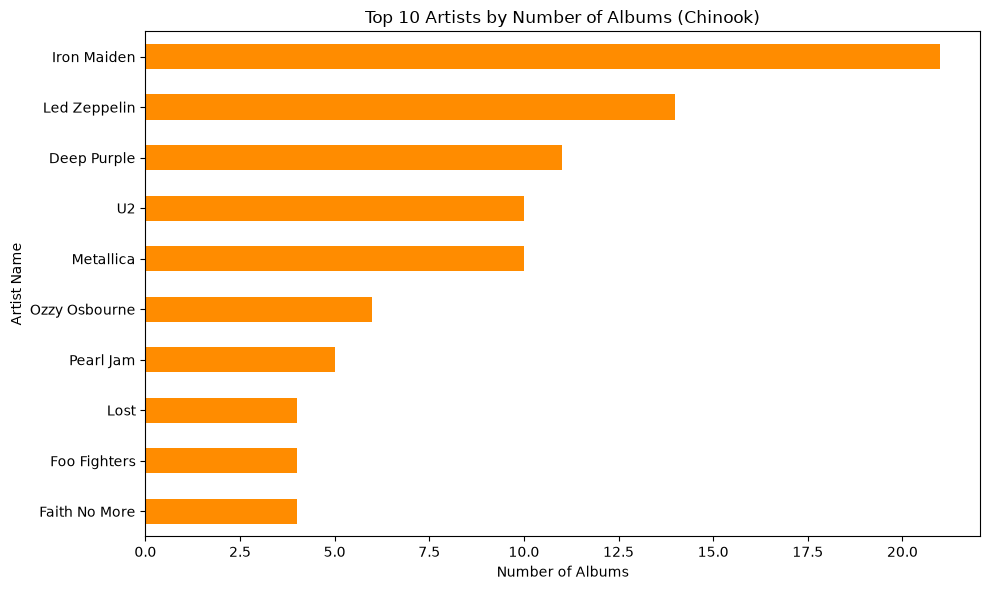

In [34]:
ax = top_10_artists_df.sort_values("AlbumCount").plot(
    kind="barh",
    x="ArtistName",
    y="AlbumCount",
    legend=False,
    figsize=(10, 6),
    color="darkorange",
)
ax.set_title("Top 10 Artists by Number of Albums (Chinook)")
ax.set_xlabel("Number of Albums")
ax.set_ylabel("Artist Name")
plt.tight_layout()
plt.show()